  Strom Koeff Waerme Koeff Abgas Koeff        PV Converter Input  \
1         0.2        0.169       0.831   3.89 MW         0.42 MW   
2         1.0       0.0338      0.9662  97.31 MW        10.48 MW   
3         0.5          0.5         0.5   3.29 MW         0.35 MW   

  Converter Output Wärme Converter Output Abgas  
1                0.35 MW                1.74 MW  
2                0.35 MW               10.12 MW  
3                0.35 MW                0.35 MW  


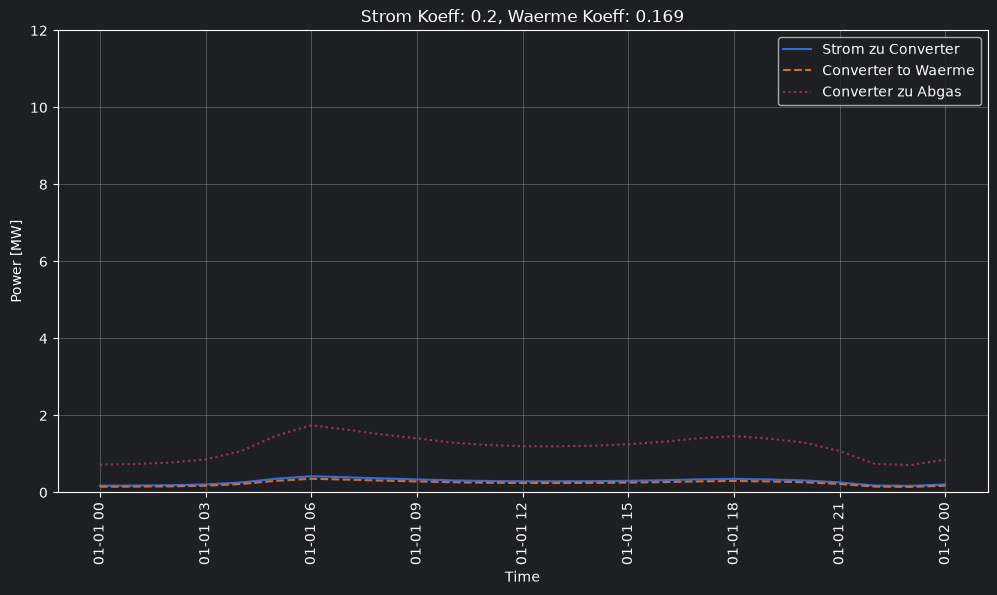

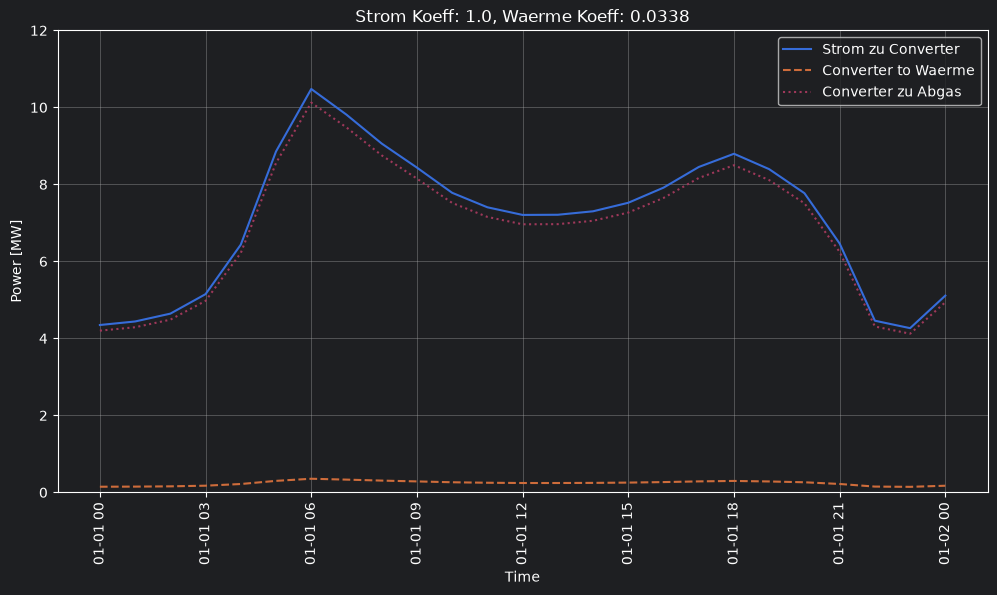

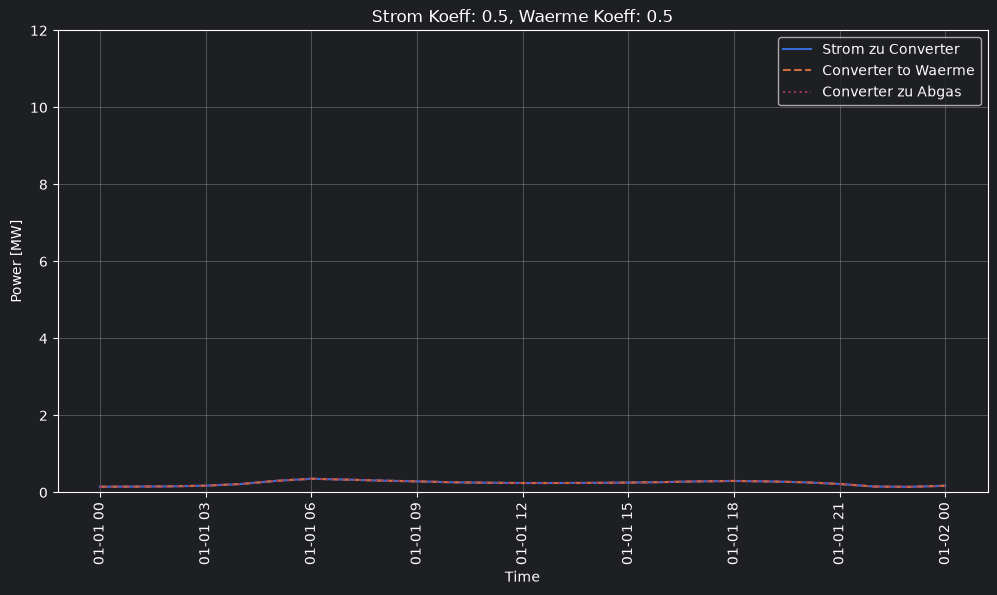

In [94]:

import matplotlib.pyplot as plt
import pandas as pd
from oemof import solph

fixture_path = pd.read_csv("input_data.csv", sep=",")
#print(fixture_path)

df = pd.DataFrame(
    columns=[
        "Strom Koeff",
        "Waerme Koeff",
        "Abgas Koeff",
        "PV",
        "Converter Input",
        "Converter Output Wärme",
        "Converter Output Abgas"
    ],
    index=range(1, 4)
)

for strom_koeff, waerme_koeff in [(0.2, 0.169), (1.0, 0.0338), (0.5, 0.5)]:
    energysystem = solph.EnergySystem(
        timeindex=pd.date_range(
            start="2025-01-01",
            end="2025-01-02",
            freq="1h",
            inclusive="both",
        ),
        infer_last_interval=True
    )

    strom_bus = solph.buses.Bus(label="Strom")
    waerme_bus = solph.buses.Bus(label="Waerme")
    abgas_bus = solph.buses.Bus(label="Abgas")

    grid = solph.components.Source(
        label="Stromnetz",
        outputs={
            strom_bus: solph.Flow(
                variable_costs=420
            )
        }
    )

    pv = solph.components.Source(
        label="PV",
        outputs={
            strom_bus: solph.Flow(
                nominal_capacity=solph.Investment(
                    ep_costs=25
                ),
                fix=fixture_path["pv"]
            )
        }
    )

    waerme_senke = solph.components.Sink(
        label="Waerme Senke",
        inputs={
            waerme_bus: solph.Flow(
                nominal_capacity=1,
                fix=fixture_path["demand_th"]
            )
        }
    )

    abgas_senke = solph.components.Sink(
        label="Abgas Senke",
        inputs={
            abgas_bus: solph.Flow()
        }
    )

    converter = solph.components.Converter(
        label="Converter 1",
        inputs={strom_bus: solph.Flow(
            nominal_capacity=solph.Investment()
        )},
        outputs={
            waerme_bus: solph.Flow(
                nominal_capacity=solph.Investment()
            ),
            abgas_bus: solph.Flow(
                nominal_capacity=solph.Investment()
            )
        },
        conversion_factors={
            strom_bus: strom_koeff,
            waerme_bus: waerme_koeff,
            abgas_bus: 1 - waerme_koeff
        }
    )

    energysystem.add(
        pv,
        grid,
        strom_bus,
        waerme_senke,
        waerme_bus,
        abgas_bus,
        converter
    )

    #graph = energysystem.to_networkx()
    #nx.draw(graph, with_labels=True, font_size=8)

    model = solph.Model(
        energysystem=energysystem
    )

    model.solve(solver="gurobi", solve_kwargs={"tee": False})
    results = solph.processing.results(model)

    plt.figure(figsize=(12, 6))
    plt.plot(
        results[(strom_bus, converter)]["sequences"],
        label="Strom zu Converter",
    )

    plt.plot(
        results[(converter, waerme_bus)]["sequences"],
        label="Converter to Waerme",
        linestyle="dashed"
    )
    plt.plot(
        results[(converter, abgas_bus)]["sequences"],
        label="Converter zu Abgas",
        linestyle="dotted"
    )
    plt.ylim(0, 12)
    plt.title(f"Strom Koeff: {strom_koeff}, Waerme Koeff: {waerme_koeff}")
    plt.xlabel("Time")
    plt.ylabel("Power [MW]")
    plt.legend()
    plt.tick_params(axis='x', rotation=90)
    plt.grid()

    df.loc[df.index[df['Strom Koeff'].isnull()][0], "Strom Koeff"] = strom_koeff
    df.loc[df.index[df['Waerme Koeff'].isnull()][0], "Waerme Koeff"] = waerme_koeff
    df.loc[df.index[df['Abgas Koeff'].isnull()][0], "Abgas Koeff"] = 1 - waerme_koeff
    df.loc[df.index[df['PV'].isnull()][0], "PV"] = f"{round(results[(pv, strom_bus)]['scalars']['invest'], 2)} MW"
    df.loc[df.index[df['Converter Output Wärme'].isnull()][0], "Converter Output Wärme"] = f"{round(results[(converter, waerme_bus)]['scalars']['invest'], 2)} MW"
    df.loc[df.index[df['Converter Output Abgas'].isnull()][0], "Converter Output Abgas"] = f"{round(results[(converter, abgas_bus)]['scalars']['invest'], 2)} MW"
    df.loc[df.index[df['Converter Input'].isnull()][0], "Converter Input"] = f"{round(results[(strom_bus, converter)]['scalars']['invest'], 2)} MW"

print(df)

